## Análisis de datos II - Clase 7
---
### Prevención de data leakage

Vamos a entrenar el mismo modelo dos veces:

1. Con leakage: con features que revelan la target y un preprocesamiento ajustado con todos los datos.
2. Sin leakage: sin las features que hacen leakage y haciendo las transformaciones después del split.

Vamos a analizar qué pasa en test pero además vamos a separar una parte de los datos para simular "producción".

Problema planteado: 
Una empresa de suscripciones quiere predecir qué clientes van a cancelar su suscripción (churn), para ofrecerles algún beneficio antes de que se vayan.

In [49]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

pd.options.display.float_format = "{:.2f}".format

## 1. Datos

Cada fila es un cliente:

- customer_id: identificador del cliente
- signup_date: fecha de alta
- plan: plan contratado (basic, standard, premium)
- monthly_spend: gasto mensual
- tenure_months: meses como cliente
- support_tickets: cantidad de reclamos a soporte
- last_login_days: días desde el último ingreso a la plataforma
- cancellation_reason: motivo de cancelación
- account_status: estado de la cuenta (active, closed)
- churned: target (1 = canceló)

In [50]:
df = pd.read_csv("../datasets/churn-data.csv")

print(f"Clientes: {len(df)}")
df.head()

Clientes: 8000


,customer_id,signup_date,plan,monthly_spend,tenure_months,support_tickets,last_login_days,cancellation_reason,account_status,churned
0,CUST-10000,2024-01-01,basic,12.95,24,2,19,no longer needed,closed,1
1,CUST-10001,2024-01-04,basic,12.34,24,2,23,NaN,active,0
2,CUST-10002,2024-01-04,basic,11.81,24,5,14,missing features,closed,1
3,CUST-10003,2024-01-04,standard,37.57,24,0,10,NaN,active,0
4,CUST-10004,2024-01-04,premium,94.87,24,2,21,NaN,active,0


In [51]:
df.isna().sum()

customer_id               0
signup_date               0
plan                      0
monthly_spend             0
tenure_months             0
support_tickets           0
last_login_days           0
cancellation_reason    5505
account_status            0
churned                   0
dtype: int64

## 2. Columnas sospechosas

Antes de modelar, miramos cómo se relaciona cada columna con la target. Para poder calcular la correlación, pasamos las categóricas a números: account_status pasa a 1 si la cuenta está cerrada, cancellation_reason a 1 si tiene un motivo cargado, y plan a variables dummy.

In [52]:
df_corr = df[["monthly_spend", "tenure_months", "support_tickets", "last_login_days", "churned"]].copy()
df_corr["account_closed"] = (df["account_status"] == "closed").astype(int)
df_corr["tiene_motivo_cancelacion"] = df["cancellation_reason"].notna().astype(int)
df_corr = df_corr.join(pd.get_dummies(df["plan"], prefix="plan", dtype=int))

correlacion = df_corr.corr(method='spearman')["churned"].drop("churned").sort_values(key=abs, ascending=False)
correlacion.to_frame("Correlación con churned")

,Correlación con churned
account_closed,1.00
tiene_motivo_cancelacion,1.00
support_tickets,0.71
plan_basic,0.27
last_login_days,0.24
monthly_spend,-0.23
plan_standard,-0.19
plan_premium,-0.11
tenure_months,-0.06


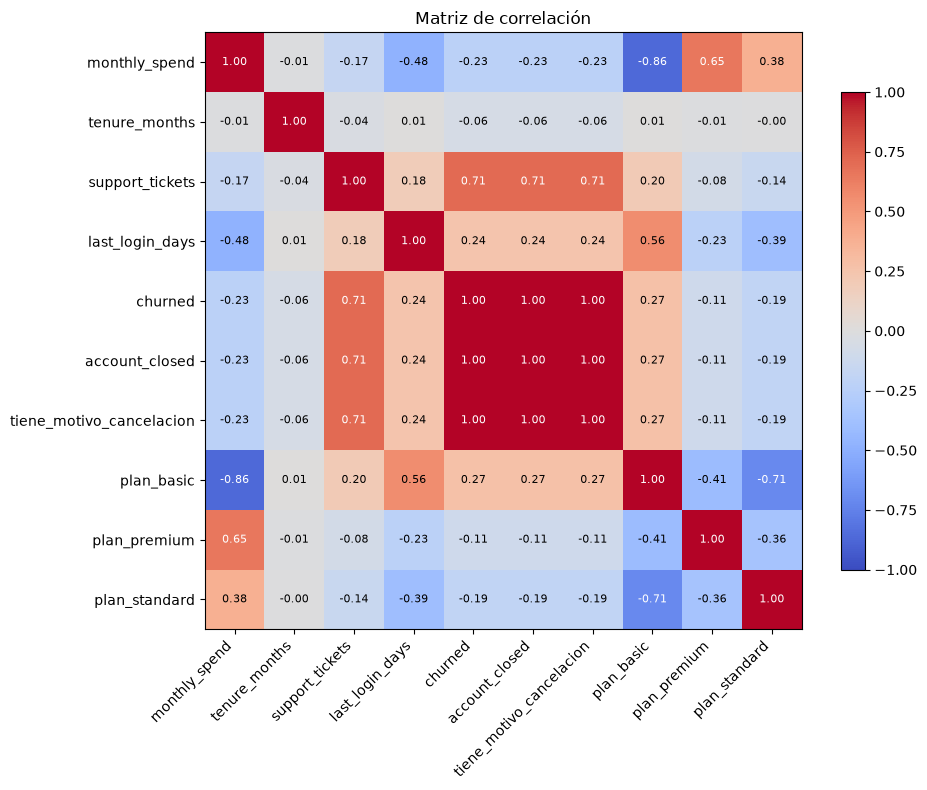

In [53]:
matriz = df_corr.corr(method='spearman')

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(matriz, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(matriz)), matriz.columns, rotation=45, ha="right")
ax.set_yticks(range(len(matriz)), matriz.columns)

for i in range(len(matriz)):
    for j in range(len(matriz)):
        valor = matriz.iloc[i, j]
        ax.text(j, i, f"{valor:.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(valor) > 0.6 else "black")

ax.set_title("Matriz de correlación")
fig.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

Obs:
- tiene_motivo_cancelacion y account_closed tienen correlación 1,00 con churned: son exactamente iguales a la target.
- El resto tiene correlaciones bajas.

Una correlación alta no alcanza para decir que hay leakage: una feature puede tener mucho poder predictivo. Por ejemplo, es razonable que un cliente que hace muchos reclamos a soporte esté por cancelar, y los reclamos se conocen antes de la cancelación. 

Una correlación de 1,00, en cambio, sí es una señal de alarma muy fuerte: ninguna feature legítima predice la target perfectamente.



Miramos en detalle las dos columnas con correlación perfecta:

In [54]:
pd.crosstab(df["account_status"], df["churned"], colnames=["Canceló"])

Canceló,0,1
account_status,,
active,5505,0
closed,0,2495


In [55]:
pd.crosstab(df["cancellation_reason"].notna(), df["churned"],
            rownames=["Tiene motivo de cancelación"], colnames=["Canceló"])

Canceló,0,1
Tiene motivo de cancelación,,
False,5505,0
True,0,2495


- account_status es la target con otro nombre: todas las cuentas cerradas son de clientes que cancelaron.
- cancellation_reason solo existe para quienes cancelaron: se registra en el momento de la baja. Esta columna tiene faltantes por diseño.

Las dos se generan después de la cancelación, así que deberíamos descartarlas. Pero vamos a ver qué pasa si no lo hacemos: las dejamos como features (convertidas a 0/1) para el modelo con leakage.

Descartamos customer_id (es un identificador) y signup_date (da la misma información que tenure_months).

In [56]:
df = df.drop(columns=["customer_id", "signup_date"])

# Las reestructuramos porque tienen nulos por diseño y las reemplazamos por una sola "tiene_motivo_cancelacion" de tipo 0/1, por simplicidad.
df["account_closed"] = (df["account_status"] == "closed").astype(int)
df["tiene_motivo_cancelacion"] = df["cancellation_reason"].notna().astype(int)
df = df.drop(columns=["account_status", "cancellation_reason"])

df.head()

,plan,monthly_spend,tenure_months,support_tickets,last_login_days,churned,account_closed,tiene_motivo_cancelacion
0,basic,12.95,24,2,19,1,1,1
1,basic,12.34,24,2,23,0,0,0
2,basic,11.81,24,5,14,1,1,1
3,standard,37.57,24,0,10,0,0,0
4,premium,94.87,24,2,21,0,0,0


## 3. Simulamos "producción"

Separamos un 20% de los clientes para predecir quiénes van a cancelar.

En el momento de predecir, ninguno canceló todavía: todas las cuentas están activas y nadie tiene un motivo de cancelación cargado. Por eso, en producción, account_closed y tiene_motivo_cancelacion valen 0 para todos.

In [57]:
historicos, produccion = train_test_split(df, test_size=0.2, random_state=42, stratify=df["churned"])

produccion = produccion.copy()
produccion["account_closed"] = 0              # nadie canceló todavía
produccion["tiene_motivo_cancelacion"] = 0    # nadie tiene un motivo de cancelación cargado

print(f"Datos históricos: {len(historicos)} clientes")
print(f"Producción: {len(produccion)} clientes")

Datos históricos: 6400 clientes
Producción: 1600 clientes


---
## 4. Con leakage

Dos errores:
1. Usamos account_closed y tiene_motivo_cancelacion como features.
2. Codificamos el plan (one-hot) y ajustamos el escalado (StandardScaler) con todos los datos, antes del split.

In [58]:
numericas = ["monthly_spend", "tenure_months", "support_tickets", "last_login_days"]
reveladoras = ["account_closed", "tiene_motivo_cancelacion"]

datos = historicos.copy()

# Error 1: agregamos train-test leakage
datos = pd.get_dummies(datos, columns=["plan"], drop_first=True, dtype=int)
escalador_todo = StandardScaler().fit(datos[numericas])
datos[numericas] = escalador_todo.transform(datos[numericas])

# Error 2: incluimos target leakage
features_leak = numericas + ["plan_premium", "plan_standard"] + reveladoras

# Hacemos el split
X_train, X_test, y_train, y_test = train_test_split(
    datos[features_leak], datos["churned"], test_size=0.2, random_state=42)

modelo_leak = LogisticRegression()
modelo_leak.fit(X_train, y_train)

acc_test_leak = accuracy_score(y_test, modelo_leak.predict(X_test))
print(f"Accuracy en test: {acc_test_leak:.2f}")

Accuracy en test: 1.00


Veamos qué pasa en producción:

In [59]:
X_prod = pd.get_dummies(produccion, columns=["plan"], drop_first=True, dtype=int)
X_prod[numericas] = escalador_todo.transform(X_prod[numericas])

acc_prod_leak = accuracy_score(produccion["churned"], modelo_leak.predict(X_prod[features_leak]))
print(f"Accuracy en producción: {acc_prod_leak:.2f}")


Accuracy en producción: 0.69


In [60]:
# Cuántos predice que cancelan el servicio??
pred_test_leak = modelo_leak.predict(X_test)
pred_prod_leak = modelo_leak.predict(X_prod[features_leak])

print(f"Test: predice que cancelan {pred_test_leak.sum()} de {len(pred_test_leak)} "
      f"(cancelaron de verdad: {y_test.sum()})")
print(f"Producción: predice que cancelan {pred_prod_leak.sum()} de {len(pred_prod_leak)} "
      f"(cancelaron de verdad: {produccion['churned'].sum()})")

Test: predice que cancelan 423 de 1280 (cancelaron de verdad: 423)
Producción: predice que cancelan 0 de 1600 (cancelaron de verdad: 499)


Obs: En producción el modelo se limita a predecir que nadie cancela...


### Analicemos en detalle:

In [61]:
print("Coeficientes del modelo:")
pd.Series(modelo_leak.coef_[0], index=features_leak)

Coeficientes del modelo:


monthly_spend               0.03
tenure_months              -0.11
support_tickets             1.32
last_login_days             0.15
plan_premium               -0.39
plan_standard              -0.28
account_closed              5.48
tiene_motivo_cancelacion    5.48
dtype: float64

Los coeficientes de account_closed y tiene_motivo_cancelacion son mucho más grandes que el resto: el modelo aprendió que si la cuenta está cerrada o hay un motivo de cancelación, el cliente canceló.

- En test funcionó porque test viene de los mismos datos históricos, donde esas columnas ya reflejan lo que pasó.
- En producción todavía nadie canceló: esas columnas valen 0 para todos y el modelo predice que nadie va a cancelar. No están disponibles en el momento de predecir, porque se generan después de la cancelación.


#### Otra forma: en vez de analizar los coeficientes podemos usar SHAP

In [62]:
import shap

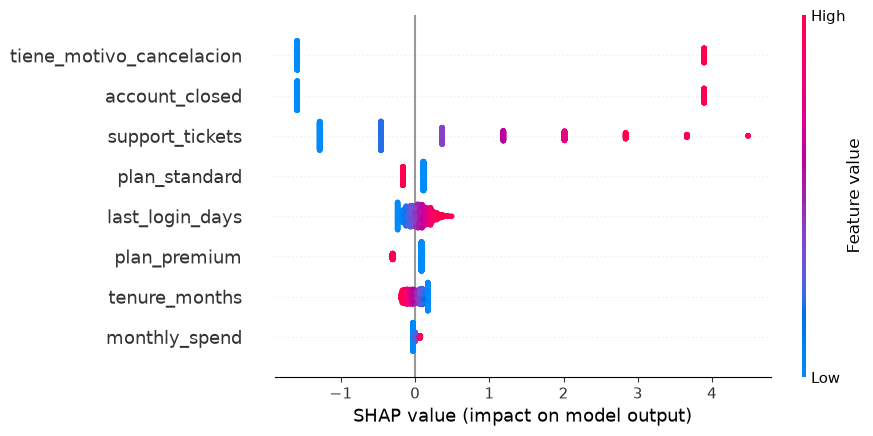

In [63]:
explainer = shap.LinearExplainer(modelo_leak, X_train)
shap_values = explainer(X_test)

shap.plots.beeswarm(shap_values)

Cada punto es un cliente de test. El eje horizontal indica cuánto empuja cada feature la predicción hacia cancelar (derecha) o hacia quedarse (izquierda), y el color indica el valor de la feature (rojo alto, azul bajo).

* tiene_motivo_cancelacion y account_closed son las features con más impacto. Cada una forma solo dos bloques separados: cuando vale 0 empuja fuerte hacia "no cancela" y cuando vale 1 empuja muy fuerte hacia "cancela". Este patrón, con efectos tan grandes y sin valores intermedios, es típico de una feature que revela la target.

* support_tickets tiene un efecto gradual: cuantos más reclamos, más empuja hacia cancelar. Es una feature legítima con poder predictivo real.
El resto de las features tiene un impacto chico.

* El modelo depende casi por completo de las dos columnas que revelan la target. En producción esas columnas valen 0 para todos, así que todos los clientes caen en el bloque que empuja hacia "no cancela".

---
## 5. Sin leakage

Corregimos los dos errores:
1. Sacamos account_closed y tiene_motivo_cancelacion.
2. Hacemos el split primero, y ajustamos la codificación y el escalado solo con train.

In [64]:
features = numericas + ["plan"]

# Buena práctica: primero el split
X_train, X_test, y_train, y_test = train_test_split(
    historicos[features], historicos["churned"], test_size=0.2, random_state=42)

# Ajustamos los mecanismos de procesamiento solo en train (y los aplicamos a train, test y producción)
codificador = OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False).fit(X_train[["plan"]])
escalador = StandardScaler().fit(X_train[numericas])

def preprocesar(X):
    return np.hstack([escalador.transform(X[numericas]), codificador.transform(X[["plan"]])])

modelo = LogisticRegression()
modelo.fit(preprocesar(X_train), y_train)

acc_test = accuracy_score(y_test, modelo.predict(preprocesar(X_test)))
acc_prod = accuracy_score(produccion["churned"], modelo.predict(preprocesar(produccion[features])))

print(f"Accuracy en test: {acc_test:.2f}")
print(f"Accuracy en producción: {acc_prod:.2f}")

Accuracy en test: 0.90
Accuracy en producción: 0.89


In [65]:
pred_test = modelo.predict(preprocesar(X_test))
pred_prod = modelo.predict(preprocesar(produccion[features]))

print(f"Producción: predice que cancelan {pred_prod.sum()} de {len(pred_prod)} "
      f"(cancelaron de verdad: {produccion['churned'].sum()})")

Producción: predice que cancelan 454 de 1600 (cancelaron de verdad: 499)


## 6. Comparación final

In [66]:
pd.DataFrame({
    "Accuracy en test": [acc_test_leak, acc_test],
    "Accuracy en producción": [acc_prod_leak, acc_prod],
}, index=["Con leakage", "Sin leakage"])

,Accuracy en test,Accuracy en producción
Con leakage,1.00,0.69
Sin leakage,0.90,0.89


## Conclusiones

- Con leakage, el test dio un resultado perfecto, pero en producción el modelo solo predice que nadie cancela. 
- Sin leakage, el resultado en test es más bajo, pero refleja la realidad: en producción el modelo rinde lo mismo.
- Un test demasiado bueno siempre debería ser una señal de alarma. En este caso, la correlación de 1,00 con la target ya lo anticipaba.
- Para cada feature, preguntar: ¿este dato existe en el momento en el que voy a predecir? account_status y cancellation_reason se generan después de la cancelación.
- Todo lo que se ajusta con los datos (escalado, imputación, codificación) debe ajustarse solo con train. En este ejemplo, codificar y escalar con todos los datos casi no cambia el resultado y casi todo el efecto viene de las columnas que revelan la target, pero es un error que hay que evitar: con otros preprocesamientos la diferencia puede ser grande.